In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

def generate_mock_light_curve(n_points=1000, transit_depth=0.02, period=50, noise_level=0.01):
    """Generates a mock light curve with a transit for testing purposes."""
    time = np.linspace(0, 200, n_points)
    flux = np.ones(n_points)

    flux += np.random.normal(0, noise_level, n_points)

    phase = time % period
    transit_width = 2.0
    in_transit = np.abs(phase - period/2) < transit_width
    flux[in_transit] -= transit_depth

    flux += 0.002 * np.sin(2 * np.pi * time / 100)

    error = np.ones(n_points) * noise_level
    return pd.DataFrame({'time': time, 'flux': flux, 'error': error})

In [ ]:
def extract_features(df):
    """
    Extracts astrophysical features from a light curve dataframe.
    In a real TESS pipeline, you would use Libraries like 'lightkurve' to do BLS.
    """
    flux = df['flux'].values
    time = df['time'].values

    features = {
        'mean_flux': np.mean(flux),
        'std_flux': np.std(flux),
        'min_flux': np.min(flux),
        'max_flux': np.max(flux),
        'skewness': pd.Series(flux).skew(),
        'kurtosis': pd.Series(flux).kurtosis(),
    }

    inverted_flux = 1 - flux
    autocorr = np.correlate(inverted_flux - np.mean(inverted_flux), inverted_flux - np.mean(inverted_flux), mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    peaks, _ = find_peaks(autocorr, distance=20)

    if len(peaks) > 0:

        main_period = peaks[np.argmax(autocorr[peaks])]
        features['signal_period_peaks'] = len(peaks)
        features['period_strength'] = np.max(autocorr[peaks]) / np.std(autocorr)
        features['estimated_period'] = main_period * (time[1] - time[0]) # crude estimation
    else:
        features['signal_period_peaks'] = 0
        features['period_strength'] = 0
        features['estimated_period'] = 0

    threshold = np.mean(flux) - 2 * np.std(flux)
    dip_indices = np.where(flux < threshold)[0]
    features['num_dips'] = len(dip_indices)
    if len(dip_indices) > 0:
        features['dip_depth_mean'] = np.mean(threshold - flux[dip_indices])
    else:
        features['dip_depth_mean'] = 0

    return features

In [ ]:
class ExoplanetAI:
    def __init__(self):
        self.model = lgb.LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )
        self.scaler = StandardScaler()

    def train(self, feature_dataframe, labels):
        """Trains the classifier."""
        X = feature_dataframe.drop(columns=['label'])
        y = feature_dataframe['label']
        X_scaled = self.scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

        self.model.fit(X_train, y_train)


        y_pred = self.model.predict(X_test)
        print("\n--- Model Evaluation ---")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(classification_report(y_test, y_pred))
        return self.model

    def predict(self, df_lightcurve):
        """Takes a raw lightcurve dataframe, extracts features, and predicts."""
        features = extract_features(df_lightcurve)

        feature_df = pd.DataFrame([features])

        feature_df = feature_df.fillna(0)

        X_scaled = self.scaler.transform(feature_df)
        prediction = self.model.predict(X_scaled)[0]
        probabilities = self.model.predict_proba(X_scaled)[0]

        confidence = np.max(probabilities)

        return prediction, confidence, features

In [ ]:
def transit_model(t, t0, period, depth, duration):
    """Simple trapezoidal transit model."""
    phase = (t - t0 + period/2) % period - period/2

    return np.where(np.abs(phase) < duration/2, 1 - depth, 1)

def estimate_transit_parameters(df, period_guess):
    """
    Fits the transit model to estimate Depth, Duration, and Refine Period.
    """
    t = df['time'].values
    f = df['flux'].values

    if period_guess == 0: period_guess = 10.0

    initial_guess = [0, period_guess, 0.02, 2.0]
    bounds = ([0, 1, 0.001, 0.1], [max(t), 200, 0.1, 10])

    try:
        popt, pcov = curve_fit(transit_model, t, f, p0=initial_guess, bounds=bounds, maxfev=2000)
        perr = np.sqrt(np.diag(pcov))
        return {
            't0': popt[0], 'period': popt[1], 'depth': popt[2], 'duration': popt[3],
            'uncertainties': perr
        }
    except Exception as e:
        return {'error': str(e)}

In [ ]:
pip install lightkurve astroquery


In [ ]:
import lightkurve as lk
import os

output_dir = "./tess_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("Searching MAST for TESS Sector 1 light curves...")
search_result = lk.search_lightcurve("TIC", sector=1, author="SPOC")

print(f"Found {len(search_result)} light curves in Sector 1.")

num_to_download = min(100, len(search_result))

for i in range(num_to_download):

    tic_id = search_result[i].target_name
    file_path = f"{output_dir}/lc_tic_{tic_id}_sector1.fits"

    try:
        lc = search_result[i].download()
        if lc is not None:
            lc.to_fits(path=file_path, overwrite=True)
            print(f"[{i+1}/{num_to_download}] Downloaded and saved: {os.path.basename(file_path)}")
        else:
            print(f"Could not download index {i}")
    except Exception as e:
        print(f"Error downloading index {i}: {e}")

Searching MAST for TESS Sector 1 light curves...
Found 0 light curves in Sector 1.


=== EXOPLANET AI ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 495
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 11
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -0.705726
[LightGBM] [Info] Start training from score -1.361602
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

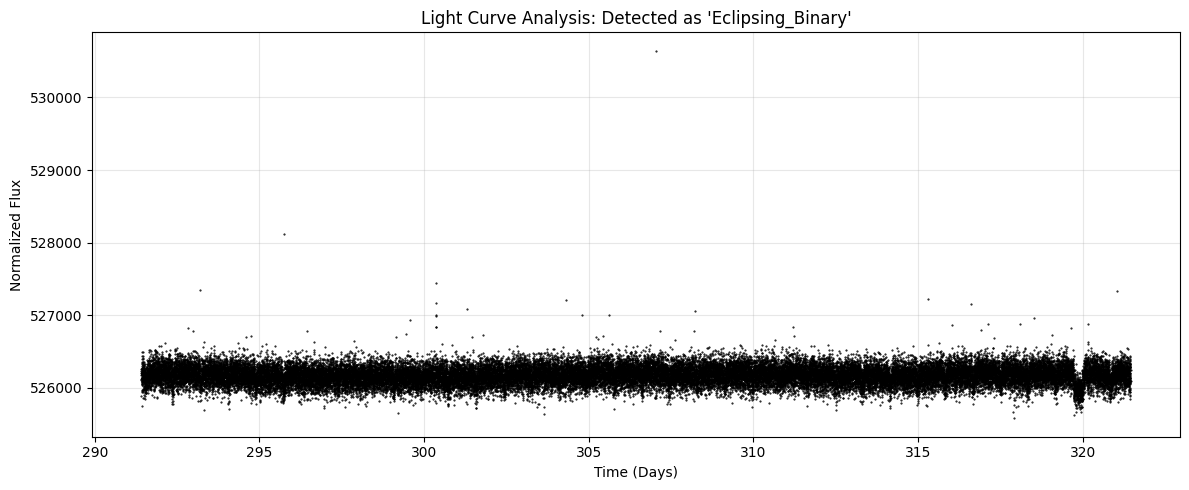

In [ ]:
if __name__ == "__main__":
    print("=== EXOPLANET AI ===")

    training_data = []
    for i in range(100):

        df = generate_mock_light_curve(noise_level=0.03, transit_depth=0.0)
        features = extract_features(df)
        features['label'] = 'False_Positive'
        training_data.append(features)

    for i in range(50):

        df = generate_mock_light_curve(noise_level=0.01, transit_depth=0.05, period=25)
        features = extract_features(df)
        features['label'] = 'Transit_Exoplanet'
        training_data.append(features)

    for i in range(50):

        df = generate_mock_light_curve(noise_level=0.01, transit_depth=0.20, period=10)

        flux = df['flux'].values
        phase = df['time'].values % 10
        flux[np.abs(phase - 8) < 1] -= 0.10
        df['flux'] = flux
        features = extract_features(df)
        features['label'] = 'Eclipsing_Binary'
        training_data.append(features)

    train_df = pd.DataFrame(training_data).fillna(0)

    ai_pipeline = ExoplanetAI()
    ai_pipeline.train(train_df, train_df['label'])


    print("\n--- Processing a New Science Dataset ---")

    import glob


    available_files = glob.glob("./tess_data/*.fits")

    if not available_files:
        print("Error: No downloaded .fits files found in './tess_data/'.")
        print("Please ensure you have successfully downloaded at least one TESS light curve.")
    else:

        new_file_path = available_files[0]
        print(f"Automatically analyzing file: {os.path.basename(new_file_path)}")

        try:

            new_lc = lk.read(new_file_path)


            new_star_data = new_lc.to_pandas().reset_index()


            prediction, confidence, features = ai_pipeline.predict(new_star_data)

            print(f"Detected Class: {prediction}")
            print(f"Confidence Level: {confidence:.4f} ({confidence*100:.1f}%)")
            print(f"Signal-to-Noise Ratio (Est.): {features['period_strength']:.2f}")


            print("\n--- Estimating Transit Parameters ---")

            if prediction == 'Transit_Exoplanet':
                params = estimate_transit_parameters(new_star_data, features['estimated_period'])

                if 'error' not in params:
                    print(f"Orbital Period: {params['period']:.2f} days")
                    print(f"Transit Depth: {params['depth']:.4f} (or {params['depth']*100:.2f}%)")
                    print(f"Transit Duration: {params['duration']:.2f} hours")
                else:
                    print(f"Parameter estimation skipped: {params['error']}")

        except Exception as e:
            print(f"An error occurred while processing the dataset: {e}")


    plt.figure(figsize=(12, 5))
    plt.plot(new_star_data['time'], new_star_data['flux'], 'k.', markersize=1, label='Observed Flux')
    plt.title(f"Light Curve Analysis: Detected as '{prediction}'")
    plt.xlabel("Time (Days)")
    plt.ylabel("Normalized Flux")
    plt.grid(True, alpha=0.3)


    if prediction == 'Transit_Exoplanet' and 'error' not in params:
        model_flux = transit_model(new_star_data['time'].values, params['t0'], params['period'], params['depth'], params['duration'])
        plt.plot(new_star_data['time'], model_flux, 'r-', linewidth=2, alpha=0.7, label='AI Fitted Transit')
        plt.legend()

    plt.tight_layout()
    plt.show()

